In [1]:
import os
import h5py
import json
import glob
import argparse
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt

from collections import defaultdict

import tbi.io_utils as io_utils
from utils.preprocess_actigraphy import preprocess_actigraphy_df
from utils.preprocess_psg import preprocess_psg_dict

In [2]:
def parse_args():
    argparser = argparse.ArgumentParser()
    argparser.add_argument(
        '--actigraphy_path',
        type = str,
        help ='Path to the directory containing the actigraphy files',
        default = '/oak/stanford/groups/mignot/actigraphy/TBI/acc/'
    )
    argparser.add_argument(
        '--edf_path',
        type = str,
        help = 'Path to the directory containing the edf files',
        default = '/oak/stanford/groups/mignot/actigraphy/TBI/edf/'
    )
    argparser.add_argument(
        '--hypno_path',
        type = str,
        help = 'Path to the directory containing the hypnogram files',
        default ='/oak/stanford/groups/mignot/actigraphy/TBI/hypnogram/'
    )
    argparser.add_argument(
        '--events_path',
        type = str,
        help = 'Path to the directory containing the event files',
        default = '/oak/stanford/groups/mignot/actigraphy/TBI/events/'
    )
    argparser.add_argument(
        '--output_dir',
        type=str,
        help = 'Directory to save the output h5 files',
        default = '/oak/stanford/groups/mignot/projects/actigraphy_fm/data/tbi/'
    )
    argparser.add_argument(
        '--config_json_path',
        type=str,
        help = 'Path to json config file',
        default = './tbi/preproc_config.json'
    )
    argparser.add_argument(
        '--f'
    )

    return argparser.parse_args()

def read_config(config_path: str, args):
    with open(config_path, 'r') as f:
        config = json.load(f)
    args.__dict__.update(config)

args = parse_args()
read_config(args.config_json_path, args)

In [3]:
# Get the paths for the actigraphy files 
act_files = glob.glob(args.actigraphy_path+'/**/*.csv', recursive=True)
edf_files = glob.glob(args.edf_path+'/**/*.edf', recursive=True)
hypno_files = glob.glob(args.hypno_path+'/**/*.csv', recursive=True)
event_files = glob.glob(args.events_path+'/**/*.csv', recursive=True)
print(f'Found {len(act_files)} actigraphy files')
print(f'Found {len(edf_files)} edf files')
print(f'Found {len(hypno_files)} hypnogram files')
print(f'Found {len(event_files)} event files')
print(' ')

# Find subjects with both actigraphy and edf
sub_ids_act = [os.path.basename(file)[:-7] for file in act_files]
sub_ids_edf = [os.path.basename(file)[:-4] for file in edf_files]
sub_ids_hypno = [os.path.basename(file)[:-4] for file in hypno_files]

edf_no_act = set(sub_ids_edf).difference(set(sub_ids_act))
act_no_edf = set(sub_ids_act).difference(set(sub_ids_edf))
act_and_edf = set(sub_ids_act).intersection(set(sub_ids_edf))
act_edf_and_hypno = act_and_edf.intersection(set(sub_ids_hypno))
print(f'No actigraphy found for following subjects with edf: {edf_no_act}')
print(f'No edf found for following subjects with actigraphy: {act_no_edf}')
print(f'{len(act_and_edf)} files found with both actigraphy and edf')
print(f'{len(act_edf_and_hypno)} files found with actigraphy, edf, and hypnogram')
print(' ')

subjects_df = io_utils.get_subjects_df(
    keep_subject_ids = act_edf_and_hypno,
    act_files = act_files,
    edf_files = edf_files,
    hypno_files = hypno_files,
    event_files = event_files,
)


Found 267 actigraphy files
Found 271 edf files
Found 274 hypnogram files
Found 274 event files
 
No actigraphy found for following subjects with edf: {'18-01088', '18-01089', '09-01017', '21-02500', '06-01186', '27-00469', '06-01190', '27-00571', '07-01182', '27-00551'}
No edf found for following subjects with actigraphy: {'27-90008', '06-01200', '09-00993', '09-02014', '06-01198', '27-90015'}
261 files found with both actigraphy and edf
260 files found with actigraphy, edf, and hypnogram
 


 
Processing 21-02516


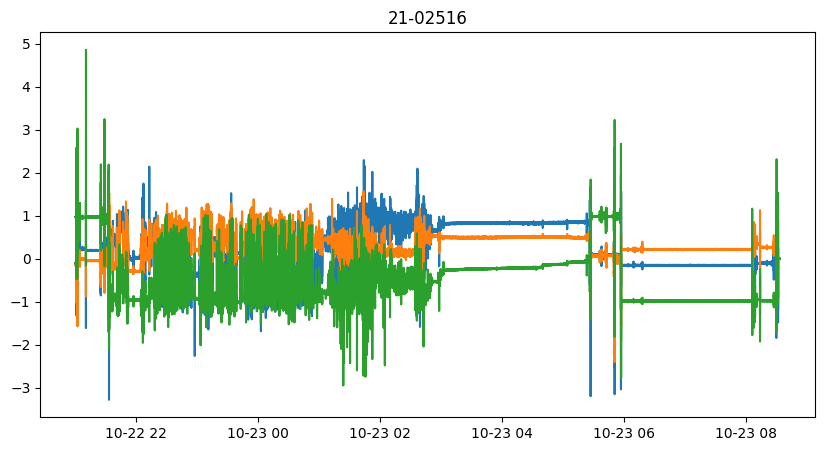

/oak/stanford/groups/mignot/projects/actigraphy_fm/code/SRL_WASSED/preprocessing/utils/preprocess_actigraphy.py:79: UserWarning:   Detected 11100 potential dropout points (zero magnitude) out of 4162700 total samples. Setting to NaN.
  else: warnings.warn(message, UserWarning)


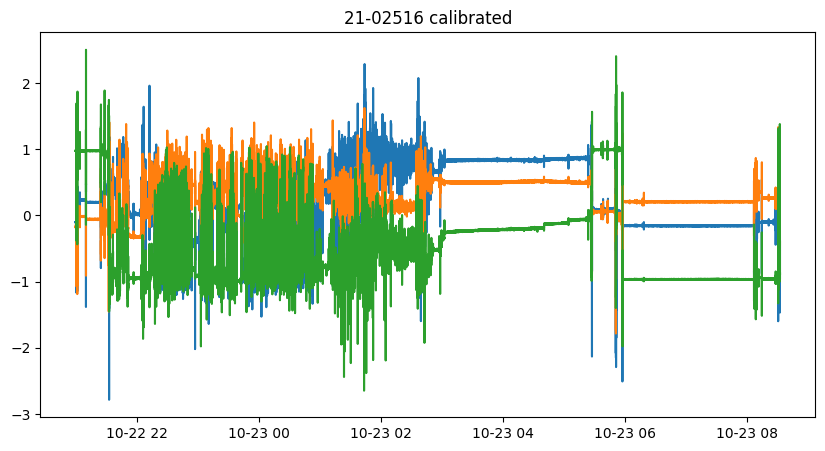

Actigraphy duration: 2018-10-22 21:00:00 - 2018-10-23 08:33:46.990000
EDF duration: 2018-10-22 22:29:22 - 2018-10-23 05:21:21.990000


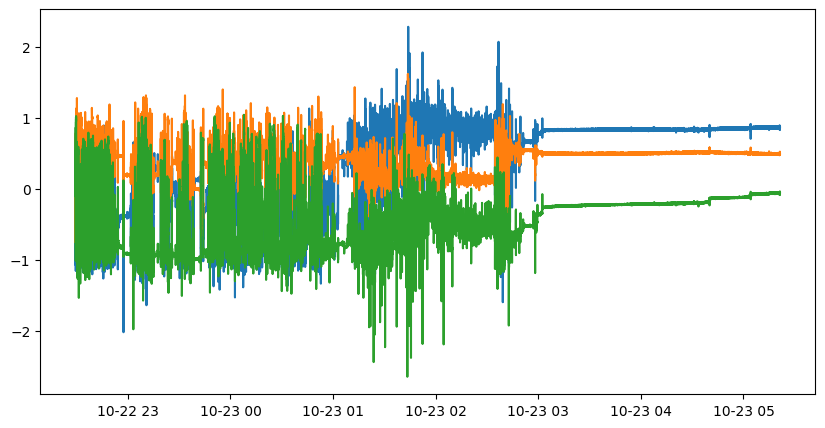

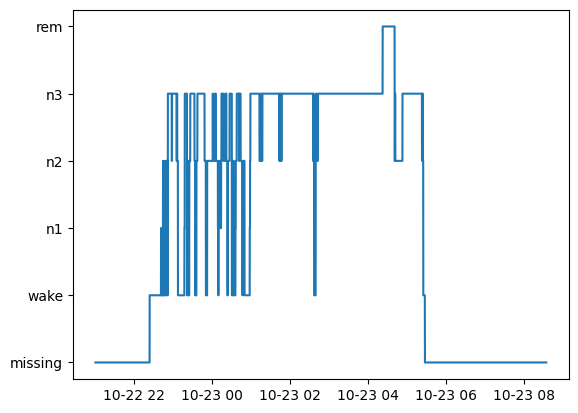

In [9]:
calib_failed = []
short_recording = []
errors = []
ahis = []
stages_count = {
    'wake': 0,
    'n1': 0,
    'n2': 0,
    'n3': 0,
    'rem': 0,
    'missing': 0
}

# Start proccessing 
for i in range(len(subjects_df)):
    if subjects_df.loc[i, 'id'] not in ['21-02516']:#, '07-07271']:
        continue
    # Skip if output file exists
    # out_file = os.path.join(args.output_dir, f'{subjects_df.loc[i, 'id']}.h5')
    # if subjects_df.loc[i, 'id'] not in ['07-01235', '21-02383']:
    #     continue
    # if os.path.exists(out_file):
    #     print(f'Skipping {subjects_df.loc[i, 'id']} since h5 file exists')
    #     continue
    print(' ')    
    print(f'Processing {subjects_df.loc[i, 'id']}')
    
    # # -- ACTIGRAPHY --
    # # Read actigraphy csv file header
    act_csv = subjects_df.loc[i, 'act']
    acc_df = io_utils.read_actigraphy_csv(act_csv)
    acc_fs_in = 1/acc_df.index.diff().mean().total_seconds()

    fig = plt.figure(figsize=(10,5))
    plt.plot(acc_df.index, acc_df.values)
    plt.title(subjects_df.loc[i, 'id'])
    plt.show()

    acc_df_preproc, all_info =  preprocess_actigraphy_df(
        data_df = acc_df,
        x_col = 'Accelerometer X',
        y_col = 'Accelerometer Y',
        z_col = 'Accelerometer Z',
        fs_in = acc_fs_in,
        fs_out = args.actigraphy_resample_freq,
        gravity_calibration = True,
        calib_cube = args.calib_cube,
        max_iters_calib = 1500,
        verbose = False,
    )

    fig = plt.figure(figsize=(10,5))
    plt.plot(acc_df_preproc.index, acc_df_preproc.values)
    plt.title(subjects_df.loc[i, 'id'] + ' calibrated')
    plt.show()

    if all_info['calibration_diagnostics']['CalibOK'] == 0:
        calib_failed.append(subjects_df.loc[i, 'act'])
        print('Skipping file due to failed calibration')
        continue

    save_info = all_info['calibration_diagnostics']

    # -- PSG --
    # Read edf with error handling
    edf_path = subjects_df.loc[i, 'edf']
    signals, signals_metadata, study_start = io_utils.read_edf(edf_path, args.psg_montage)

    # Dowsample signals to 100Hz and apply anti-aliasing
    signals, signals_metadata = preprocess_psg_dict(
        signals,
        signals_metadata,
        fs_out = args.psg_resample_freq,
        filter_order = args.psg_filter_order,
        standardization = args.standardize_psg,
    )

    # Rename psg channels if specified
    signals = {
        (args.psg_rename_map[name]
        if name in args.psg_rename_map.keys()
        else name): signal 
        for name, signal in signals.items()
    }
    signals_metadata = {
        (args.psg_rename_map[name]
        if name in args.psg_rename_map.keys()
        else name): metadata 
        for name, metadata in signals_metadata.items()
    }
    
    # Calculate start and end time of EDF recording from ranomd signal
    sig = signals[list(signals.keys())[0]]
    fs = signals_metadata[list(signals.keys())[0]]['sample_frequency']
    edf_time = pd.date_range(start=study_start, periods=len(sig), freq=f'{1/fs}s')

    print(f'Actigraphy duration: {acc_df.index[0]} - {acc_df.index[-1]}')
    print(f'EDF duration: {edf_time[0]} - {edf_time[-1]}')
    
    same_start_date = edf_time[0].date() == acc_df.index[0].date()
    if not same_start_date:
        print('Actrigraphy and EDF do not have same start dates')

    act_before_edf_start = acc_df.index[0] < edf_time[0]
    act_after_edf_end = acc_df.index[-1] > edf_time[-1]

    start_time = edf_time[0] if act_before_edf_start else acc_df.index[0]
    end_time = edf_time[-1] if act_after_edf_end else acc_df.index[-1]
 
    if (end_time - start_time).total_seconds()/60**2 < args.min_recording_hours:
        print(f'Less than {args.min_recording_hours} of concurrent data for {subjects_df.loc[i, 'id']}, skipping.')
        short_recording.append(subjects_df.loc[i, 'id'])
        continue

    # Truncate actigraphy and psg to only the extent of the concurrent data
    edf_start_idx = edf_time.get_loc(edf_time.asof(start_time))
    edf_end_idx = edf_time.get_loc(edf_time.asof(end_time))
    for channel, signal in signals.items():
        signals[channel] = signal[edf_start_idx: edf_end_idx]

    acc_df_preproc_trunc = acc_df_preproc.loc[start_time: end_time].copy()
    
    # Check for nonwear in remaining data
    std_roll = acc_df_preproc_trunc.rolling(window = '10s').std().max(axis=1)
    no_move = std_roll.rolling(window='7200s').max() < 0.015
    no_move_prcnt = no_move.sum() / len(acc_df_preproc_trunc)
    if no_move_prcnt > 0.1:
        print(f'More than 10% ({round(no_move_prcnt*100)}%) possible nonwear detected for {subjects_df.loc[i, 'act']}, skipping. \n')
        errors.append(subjects_df.loc[i, 'id'])
        continue

    fig = plt.figure(figsize=(10,5))
    plt.plot(acc_df_preproc_trunc.index, acc_df_preproc_trunc.values)
    plt.show()

    if np.any(acc_df_preproc_trunc.isna()['Accelerometer X_preprocessed']):
        print(f'NANs detected in the actigrapy signal after truncating to EDF for {subjects_df.loc[i, 'act']} \n')
        errors.append(subjects_df.loc[i, 'id'])
        continue
        
    # Read event and hypnogram labels and match them to the acti_df index
    hypnogram_df = io_utils.get_hypnogram(
        time_index = acc_df_preproc_trunc.index,
        hypno_path = subjects_df.loc[i, 'hypno'],
        study_start = study_start
    )

    plt.plot(hypnogram_df['hypnogram'])
    plt.show()

    event_df = io_utils.get_events(
        time_index = acc_df_preproc_trunc.index,
        event_path = subjects_df.loc[i, 'event'],
        study_start = study_start
    )
    annot_df = hypnogram_df.join(event_df)

    # Count AHI by apnea/hypopnea (onset+offset)//2
    num_apnea = (annot_df['apnea'] == 'none').diff().sum()//2 
    hours = (annot_df.index[-1] - annot_df.index[0]).total_seconds()/60**2
    ahi = round(num_apnea/hours,3)
    ahis.append(ahi)

    # Get sleep stage amounts
    stages_hours = {}
    for stage in annot_df['hypnogram'].unique():
        stage_hours = round(
            (annot_df['hypnogram'] == stage).sum() 
            / args.actigraphy_resample_freq / 60**2,
            3
        )
        stages_count[stage] += stage_hours
        stages_hours[stage] = stage_hours


    # # Write the data to an h5 file
    # io_utils.write_h5(
    #     out_file,
    #     accelerometry = acc_df_preproc_trunc,
    #     acc_info = save_info,
    #     x_col = 'Accelerometer X_preprocessed',
    #     y_col = 'Accelerometer Y_preprocessed',
    #     z_col = 'Accelerometer Z_preprocessed',
    #     annotations = annot_df,
    #     chunk_size_sec = args.hdf5_chunksize_sec,
    #     psg_data = signals,
    #     psg_metadata = signals_metadata,
    #     study_start = start_time,
    #     ahi = ahi,
    #     stage_hours = stages_hours,
    # )
    # print(f'Finished writing {out_file}')
    print(' ')


In [ ]:
print(f'{len(calib_failed)} files dropped due to failed calibration.')
print(f'{len(short_recording)} files dropped due to short recordings.')
ahi_a = np.array(ahis)
apnea_dict = {
    'none': (ahi_a < 5).sum(),
    'mild': (ahi_a < 15).sum() - (ahi_a < 5).sum(),
    'moderate': (ahi_a < 30).sum() - (ahi_a < 15).sum(),
    'severe': (ahi_a >= 30).sum()
}
for degree, num in apnea_dict.items():
    print(f'Number of individual with {degree} apnea: {num}/{len(ahi_a)}')

total_time = 0
for stage, time in stages_count.items():
    total_time += time
for stage, time in stages_count.items():
    print(f'% time in {stage}: {round(time/total_time,3)}')
